In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures

sales_data = pd.read_csv('https://www.statlearning.com/s/Advertising.csv', index_col=0)

# Exercise 1
### Visualize data as a heatmap and in another way of your choice.

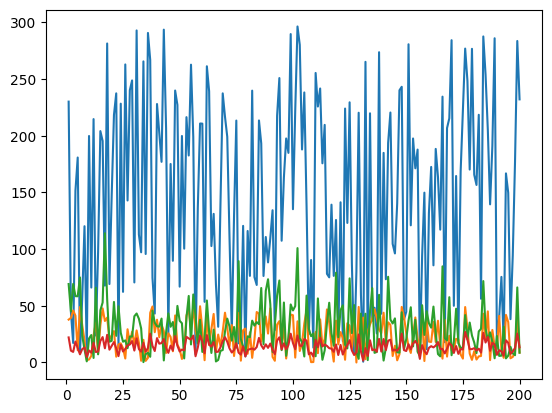

In [2]:
plt.plot(sales_data)

# Exercise 2
### a) Fit a simple linear regression model of every advertisement medium and print their summaries. (You should also try to understand them.)
### Hint: Don't forget to split the data into training and test sets!
### b) Fit a tviple linear regression model and print the summary

In [ ]:
TV = "TV"
NEWSPAPER = "newspaper"
RADIO = "radio"
SALES = "sales"

#TV
x = sm.add_constant(sales_data[TV])
y = sales_data[SALES]

tv_x_train, tv_x_test, tv_y_train, tv_y_test = train_test_split(
    x, y, test_size= .2
)

tv_lm = sm.OLS(tv_y_train, tv_x_train).fit()
print(tv_lm.summary())

#Radio
x = sm.add_constant(sales_data[RADIO])
y = sales_data[SALES]

radio_x_train, radio_x_test, radio_y_train, radio_y_test = train_test_split(
    x, y, test_size= .2
)

radio_lm = sm.OLS(radio_y_train, radio_x_train).fit()
print(radio_lm.summary())

#News
x = sm.add_constant(sales_data[NEWSPAPER])
y = sales_data[SALES]

news_x_train, news_x_test, news_y_train, news_y_test = train_test_split(
    x, y, test_size= .2
)

news_lm = sm.OLS(news_y_train, news_x_train).fit()
print(news_lm.summary())





                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.619
Model:                            OLS   Adj. R-squared:                  0.616
Method:                 Least Squares   F-statistic:                     256.3
Date:                Fri, 17 Apr 2026   Prob (F-statistic):           6.76e-35
Time:                        19:06:23   Log-Likelihood:                -409.16
No. Observations:                 160   AIC:                             822.3
Df Residuals:                     158   BIC:                             828.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          7.0038      0.496     14.119      0.0

In [4]:
#b
x = sales_data[[TV, RADIO, NEWSPAPER]]
y = sales_data[SALES]

x = sm.add_constant(x)

mult_x_train, mult_x_test , mult_y_train, mult_y_test = train_test_split(
    x, y, test_size=.2
)


mult_lm = sm.OLS(mult_y_train, mult_x_train).fit()

print(mult_lm.summary())


                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.896
Model:                            OLS   Adj. R-squared:                  0.894
Method:                 Least Squares   F-statistic:                     450.1
Date:                Fri, 17 Apr 2026   Prob (F-statistic):           1.47e-76
Time:                        19:06:23   Log-Likelihood:                -313.71
No. Observations:                 160   AIC:                             635.4
Df Residuals:                     156   BIC:                             647.7
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.0078      0.349      8.627      0.0

# Exercise 3
### a) Visualize any one of the simple linear regression models and the multiple linear regression model as plots

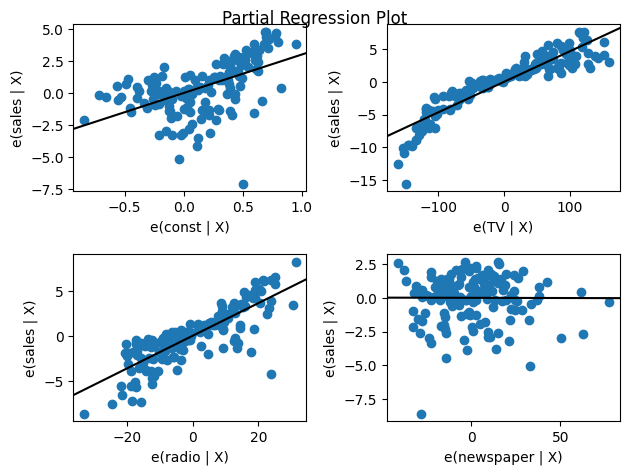

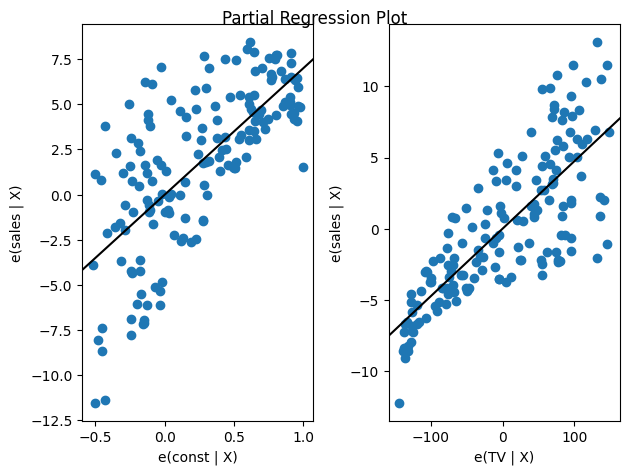

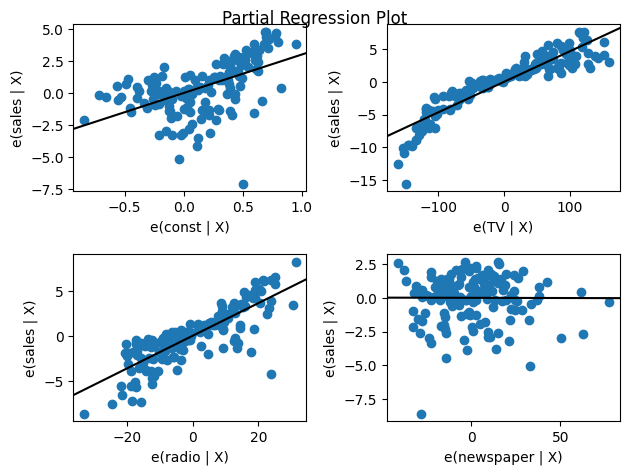

In [5]:
sm.graphics.plot_partregress_grid(tv_lm)
sm.graphics.plot_partregress_grid(mult_lm)




# Exercise 4
### Fit the TV sales into a polynomial regression model with degree=4, print the summary and visualize the model as a plot

R_Squared prediction: 0.5651404246976846
                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.634
Model:                            OLS   Adj. R-squared:                  0.625
Method:                 Least Squares   F-statistic:                     67.23
Date:                Fri, 17 Apr 2026   Prob (F-statistic):           6.84e-33
Time:                        19:06:24   Log-Likelihood:                -405.78
No. Observations:                 160   AIC:                             821.6
Df Residuals:                     155   BIC:                             836.9
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      

<Axes: xlabel='TV', ylabel='sales'>

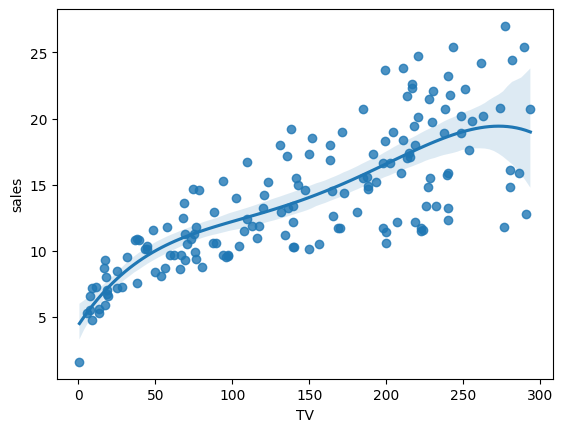

In [6]:
from sklearn.metrics import mean_squared_error, r2_score

tv_poly = PolynomialFeatures(degree=4)
tv_x_train_poly = tv_poly.fit_transform(tv_x_train)
tv_poly_lm = sm.OLS(tv_y_train, tv_x_train_poly).fit()

tv_poly_y_pred = tv_poly_lm.predict(tv_poly.transform(tv_x_test))

rsquared = r2_score(tv_y_test,tv_poly_y_pred )
print(f"R_Squared prediction: {rsquared}" )

print(tv_poly_lm.summary())

sns.regplot(x=tv_x_train[TV], y=tv_y_train, data=sales_data, order=4)


# Exercise 5
### Repeat Exercise 4 with degree=10 and note down your observations.

                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                      -0.358
Model:                            OLS   Adj. R-squared:                 -0.393
Method:                 Least Squares   F-statistic:                    -10.21
Date:                Fri, 17 Apr 2026   Prob (F-statistic):               1.00
Time:                        19:06:24   Log-Likelihood:                -510.75
No. Observations:                 160   AIC:                             1032.
Df Residuals:                     155   BIC:                             1047.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       3.854e-15   4.55e-16      8.463      0.0

<Axes: xlabel='TV', ylabel='sales'>

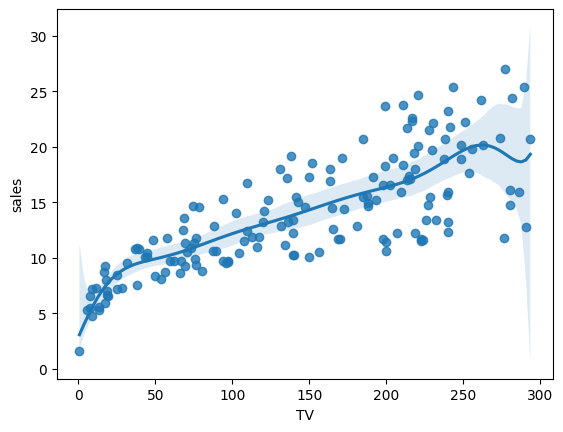

In [7]:
tv_poly = PolynomialFeatures(degree=10)

tv_x_train_poly = tv_poly.fit_transform(tv_x_train)
tv_poly_lm = sm.OLS(tv_y_train, tv_x_train_poly).fit()
print(tv_poly_lm.summary())

sns.regplot(x=tv_x_train[TV], y=tv_y_train, data=sales_data, order=10)

## Code for the PDF exercise:

In [8]:
import numpy as np

In [9]:
#linear
tv_y_pred = tv_lm.predict(tv_x_test)


mse = mean_squared_error(tv_y_test, tv_y_pred)
rmse = mse ** .5

rtwo = r2_score(tv_y_test, tv_y_pred)
rtwo

0.5857155982429434

In [10]:
#polynomal reg., degree = 10

poly_tv_y_pred = tv_poly_lm.predict(tv_poly.fit_transform(tv_x_test))

mse = mean_squared_error(tv_y_test, poly_tv_y_pred)
rmse = mse ** .5

rtwo = r2_score(tv_y_test, poly_tv_y_pred)
rtwo

-0.17891446801558186

### Selbst test:

In [18]:
x = sales_data[[TV, RADIO, NEWSPAPER]]
y = sales_data[SALES]



def compare_polys(X, Y) -> tuple[int, float, float]:

    train_x, test_x, train_y, test_y = train_test_split(X, Y, test_size=.2);

    best_degree:int = 1
    best_test_r2:float = 0
    best_train_r2:float =  0
    
    for i in range(1, 10):

        #print(f"Current degree: {i}")

        poly = PolynomialFeatures(i)

        x_poly = poly.fit_transform(train_x)

        lm  = sm.OLS(train_y, x_poly).fit()
        
        train_r2 = lm.rsquared
        #print(train_r2)

        y_predict = lm.predict(poly.transform(test_x))

        test_r2 = r2_score(y_true=test_y, y_pred=y_predict)
        #print(test_r2)


        if test_r2 > best_test_r2:
            best_train_r2 = train_r2
            best_test_r2 = test_r2
            best_degree = i

        

    return best_degree, best_test_r2, best_train_r2
    


degrees: list[int]      = []
test_r2s: list[float]   = []
train_r2s:list[float]   = []


for _ in range(1 , 100):
    d, te, tr = compare_polys(x, y)

    degrees.append(d)
    test_r2s.append(te)
    train_r2s.append(tr)

print(degrees)
print(f"Best degree: {np.mean(degrees)}")

#also not a good measurement, as 3 and 5 seem to be good, resulting in a mean of 4




[4, 3, 5, 4, 3, 3, 5, 5, 3, 2, 2, 3, 5, 4, 4, 3, 5, 5, 3, 2, 3, 4, 3, 3, 5, 5, 3, 3, 4, 5, 4, 3, 3, 4, 3, 4, 3, 5, 3, 5, 5, 3, 3, 5, 5, 3, 2, 4, 4, 3, 4, 5, 3, 3, 3, 5, 3, 3, 3, 5, 5, 4, 4, 3, 5, 2, 3, 3, 4, 3, 3, 3, 3, 5, 3, 3, 3, 4, 3, 4, 3, 5, 5, 4, 5, 4, 5, 3, 3, 2, 3, 5, 3, 2, 4, 3, 5, 4, 5]
Best degree: 3.686868686868687


In [19]:
def collatz(n:int, depth:int = 0) -> int:


    if n == 1:
        return depth

    if n % 2 == 0:
        return collatz(n // 2, depth + 1)
    else:
        return collatz(3 * n + 1, depth + 1)

In [29]:
depthxy:list[int] = []
    
for i in range(1, 100001):

    depthxy.append(collatz(i))

df = pd.DataFrame({
    "n": range(1, 100001),
    "depth": depthxy
})


In [22]:
degrees: list[int]      = []
test_r2s: list[float]   = []
train_r2s:list[float]   = []

for _ in range(1 , 100):
    d, te, tr = compare_polys(
        df[["n"]],
        df.depth
        )

    degrees.append(d)
    test_r2s.append(te)
    train_r2s.append(tr)

print(degrees)
print(f"Best degree: {np.mean(degrees)}")

[4, 4, 4, 3, 2, 3, 3, 5, 1, 5, 1, 3, 5, 3, 4, 4, 4, 1, 4, 4, 3, 5, 2, 5, 3, 5, 4, 5, 4, 4, 1, 4, 4, 2, 4, 1, 4, 4, 6, 5, 1, 5, 1, 4, 5, 4, 5, 4, 3, 4, 4, 4, 5, 2, 5, 1, 6, 3, 4, 4, 4, 4, 2, 4, 1, 2, 4, 2, 3, 2, 2, 5, 5, 3, 3, 4, 1, 1, 2, 3, 4, 1, 5, 3, 3, 2, 4, 4, 1, 5, 4, 4, 3, 4, 4, 5, 4, 4, 4]
Best degree: 3.4444444444444446


<Axes: xlabel='n', ylabel='depth'>

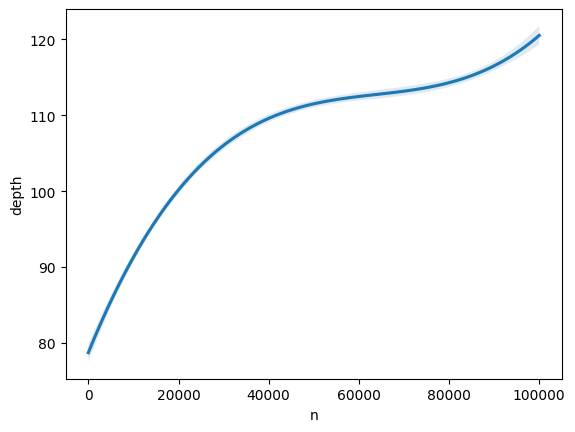

In [31]:
sns.regplot(x="n", y="depth", data=df, order=3, scatter= False)